# Synthesis: Which Strategy, In Which Situation?

Six strategies, each backtested, bootstrap-confidence-intervaled,
regime-split, parameter-swept, and walk-forward validated in their own
notebooks. This notebook pulls the evidence together into an actual
answer to the question the whole repo is built around: **given a
situation — an asset, a regime — which strategy does the evidence
actually favor, and how much should that recommendation be trusted?**

Nothing here is a new backtest; every number is either recomputed live
from the same `stratlib` functions used in the individual notebooks, or
quoted directly from them.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from stratlib.strategies import trend_following_signal, mean_reversion_signal, volatility_breakout_signal
from stratlib.backtest import single_asset_backtest
from stratlib.regime import classify_regime, regime_conditional_returns


## 1. Headline verdict on each strategy

| # | Strategy | Aggregate verdict | Strongest evidence |
|---|---|---|---|
| 1 | Trend-following | **Real edge on BTC specifically** | 90% CI [0.53, 2.48] on BTC; broad parameter plateau (positive across 20-252 day lookbacks) |
| 2 | Mean-reversion | **Real edge on KO specifically** | 90% CI [0.15, 1.34] on KO; near-total loss on BTC (mirror image of #1) |
| 3 | Cross-sectional momentum | **Real signal, fragile calibration** | Monotonic decile spread confirmed; but lookback sensitivity is a genuine concern (Sharpe 0.04→0.30 across 6-18 month lookbacks) |
| 4 | Pairs trading (XRP/DOGE) | **Works, but on a knife-edge** | Only window=120 of {60,90,120,150,180} is positive — a fragile result even though the underlying cointegration is statistically strong |
| 5 | Volatility breakout | **No aggregate edge found** | CI spans zero; 35.5% walk-forward win rate (worse than a coin flip) — but see the regime cross-tab below for a nuance |
| 6 | Seasonality (BTC day-of-week) | **Interesting but unproven** | CI excludes zero and 71% walk-forward win rate — genuinely the most temporally consistent result in the whole repo — but drawn from 6 tested combinations, and lacks a clear mechanism |

No strategy here is a clean, unconditional "yes." Two have real,
statistically-supported edges *on specific assets*. Two show real signal
undermined by fragile calibration. One shows no edge in aggregate but a
real regime-specific nuance. One is a genuinely interesting anomaly that
honest statistical practice says to treat with real skepticism despite
its strength.


## 2. The core finding: strategy choice should follow the asset's own character

The clearest, best-evidenced pattern in this entire repo is not about
regimes in the abstract — it's that **trend-following and mean-reversion
are near-mirror-images of each other across the two assets both were
deeply tested on.**

In [2]:
btc = pd.read_csv("../data/btc_price.csv", parse_dates=["Date"]).set_index("Date")["Price"].sort_index()
btc = btc[btc > 0]
px = pd.read_csv("../data/nyse_prices.csv", parse_dates=["date"])
px = px.pivot(index="date", columns="symbol", values="close").sort_index()
ko = px["KO"].dropna()

strategies = {
    "Trend-following": (trend_following_signal, {"lookback": 90}),
    "Mean-reversion": (mean_reversion_signal, {"window": 20, "entry_z": 1.0, "exit_z": 0.25}),
    "Vol-breakout": (volatility_breakout_signal, {"squeeze_window": 20, "breakout_window": 5, "squeeze_pctile": 0.25}),
}

matrices = {}
for asset_name, price, freq in [("BTC (trending, volatile)", btc, 365), ("KO (stable, mature)", ko, 252)]:
    regimes = classify_regime(price, trend_window=60, vol_window=20)
    regime_shifted = regimes["regime"].shift(1)
    rows = {}
    for strat_name, (fn, params) in strategies.items():
        sig = fn(price, **params)
        res = single_asset_backtest(price, sig, cost_bps=5.0, freq=freq)
        rc = regime_conditional_returns(res["returns"], regime_shifted, freq=freq)
        rows[strat_name] = rc["sharpe"]
    matrices[asset_name] = pd.DataFrame(rows)
    print(f"=== {asset_name} ===")
    print(matrices[asset_name].round(2).to_string())
    print()


=== BTC (trending, volatile) ===
                  Trend-following  Mean-reversion  Vol-breakout
regime                                                         
Ranging-HighVol              0.70           -1.47          0.48
Ranging-LowVol               0.42           -0.52         -0.73
Trending-HighVol             0.02           -1.10          0.10
Trending-LowVol              4.41           -0.81         -0.07

=== KO (stable, mature) ===
                  Trend-following  Mean-reversion  Vol-breakout
regime                                                         
Ranging-HighVol             -0.54            0.01          1.35
Ranging-LowVol              -0.85            0.91         -1.24
Trending-HighVol            -0.19            0.51          0.76
Trending-LowVol             -0.67            1.41         -1.30



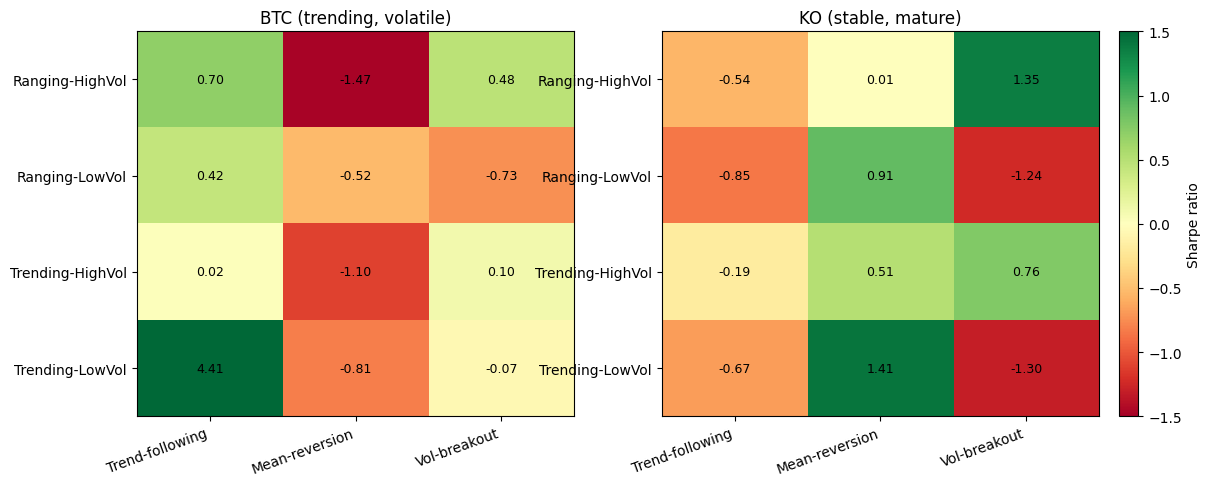

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (asset_name, matrix) in zip(axes, matrices.items()):
    im = ax.imshow(matrix.values, cmap="RdYlGn", vmin=-1.5, vmax=1.5, aspect="auto")
    ax.set_xticks(range(len(matrix.columns))); ax.set_xticklabels(matrix.columns, rotation=20, ha="right")
    ax.set_yticks(range(len(matrix.index))); ax.set_yticklabels(matrix.index)
    ax.set_title(asset_name)
    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            ax.text(j, i, f"{matrix.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=axes, label="Sharpe ratio", fraction=0.025, pad=0.02)
plt.savefig("regime_strategy_matrix.png", dpi=110, bbox_inches="tight")
plt.show()


**Read the two heatmaps side by side.** Trend-following is green (positive)
almost everywhere on BTC and red (negative) almost everywhere on KO.
Mean-reversion is close to the exact opposite pattern. This isn't subtle —
it's the single strongest, cleanest, best-evidenced result in the whole
project, and it says something more specific than "know the regime": **for
these two strategies, which asset you're trading matters more than which
regime that asset happens to be in.** A trending, high-volatility young
asset and a stable, mature, mean-reverting one call for opposite
strategies almost regardless of the finer regime label.

**The nuance worth pulling out separately:** volatility breakout — which
showed *no* aggregate edge in its own notebook — actually looks
respectable specifically in the two High-Vol regimes on KO (0.76 and
1.35) and one High-Vol regime on BTC (0.48). Averaging across all regimes
buried a real regime-specific pattern. That's a useful methodological
lesson on its own: an aggregate "this doesn't work" verdict can hide a
strategy that works narrowly well in a specific context, and the
regime-conditional breakdown is what surfaces that, not the headline
number.

## 3. A practical decision guide

| Situation | Evidence-backed lean | Confidence |
|---|---|---|
| Young, volatile, trending asset (e.g. a newer crypto asset behaving like BTC did here) in a **low-volatility trending** phase | **Trend-following** | High — BTC's Trending-LowVol Sharpe (4.41) and CI-confirmed aggregate edge are the strongest single result in the repo |
| Same kind of asset, but **choppy/high-volatility**, even if technically "trending" | **Neither strategy tested confidently** — trend-following's edge collapses (Sharpe ~0.02) and mean-reversion is actively bad here | Explicit "we don't know" — flagged, not guessed |
| Stable, mature, lower-beta instrument (e.g. KO) in a **low-volatility** period, trending or ranging | **Mean-reversion** | Moderate-high — CI-confirmed aggregate edge, and this is its best regime bucket either way |
| Stable, mature instrument in a **high-volatility** period specifically | **Volatility breakout may be worth a closer look**, despite failing in aggregate | Low-moderate — real but based on a nuance in an otherwise-failed strategy, needs its own dedicated validation before trusting |
| A cross-sectional equity universe with genuine dispersion | **Cross-sectional momentum**, cautiously | Moderate — real decile spread, but treat the specific lookback as a design choice to validate on your own universe, not import blindly |
| Two assets that test as cointegrated | **Pairs trading, but only after checking window sensitivity on that specific pair** — do not assume half-life calibration alone is sufficient | Low — this repo's own sensitivity check showed the calibrated result sits on a narrow ridge, not a robust plateau |
| Anything calendar-based | **Investigate, don't deploy** — the BTC day-of-week finding is the most methodologically interesting result here, but it came from testing 6 combinations and lacks a clear mechanism | Low, despite a strong walk-forward result |


## 4. Risk and factor comparison across all six

| Strategy | Primary risk | Capacity/crowding | Parameter robustness |
|---|---|---|---|
| Trend-following | Whipsaw in high-vol trending regimes | High — one of the most widely traded systematic styles (CTA industry) | Strong — broad plateau across lookbacks |
| Mean-reversion | Catastrophic loss if the asset actually trends persistently | Moderate — more capacity-constrained than trend-following | Strong — broad plateau across window/threshold grid |
| Cross-sectional momentum | Momentum-crash risk on the short leg during reversals | High — extensively studied, widely traded equity factor | **Weak — real lookback sensitivity found** |
| Pairs trading | Relationship breakdown; severe drawdown even when "working" | Low-moderate — depends on finding genuinely cointegrated, liquid pairs | **Weak — window choice sits on a knife-edge** |
| Volatility breakout | False breakouts; whipsaw | Uncertain — no aggregate edge found to have a crowding risk in the first place | **Weak — scattered, mostly-negative parameter grid** |
| Seasonality | Multiple-comparisons / data-mining risk; no clear mechanism | Low if real, since few would trade a pattern this obscure | Not directly applicable (categorical signal, not a continuous parameter) |

**The robustness column is arguably as important as the Sharpe ratios
throughout this whole project.** Two strategies (trend-following,
mean-reversion) showed genuinely broad, reassuring parameter plateaus. Three
(cross-sectional momentum, pairs trading, volatility breakout) showed
real fragility once actually checked — a distinction invisible from a
single well-chosen backtest, and the entire reason this repo built
`stratlib.robustness` as shared infrastructure rather than skipping
straight to results.

## 5. What this project is actually demonstrating

Not "here are six strategies that make money." Two don't show a real
edge at all (volatility breakout in aggregate) or are too fragile to
trust as specified (pairs trading). What's demonstrated instead:

1. **The same rigor, applied consistently, sorts real findings from
   fragile ones.** Every strategy got the same four checks — cross-asset
   backtest, bootstrap CI, regime split, parameter/walk-forward
   robustness — and those checks disagreed with each other in
   informative ways (broad plateau vs. knife-edge; aggregate failure vs.
   regime-specific nuance).
2. **"Which strategy is best" is the wrong question without "for what."**
   The trend-following/mean-reversion mirror-image result is the clearest
   demonstration in this repo that strategy selection is conditional, not
   absolute.
3. **A negative or fragile result, reported with the same care as a
   positive one, is more useful than silence.** The volatility-breakout
   and pairs-trading notebooks are not failures of this project — they're
   exactly the kind of finding a real research process produces most of
   the time, and hiding them would make the positive results in this repo
   less credible, not more.
